In [1]:
import zipfile, os
import tensorflow as tf

In [2]:
zip_path = "Brain_Tumor_MRI_Dataset-20260903T064520Z-1-001.zip"
extract_path = "brain_tumor_data"

In [3]:
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

In [4]:
data_dir = os.path.join(extract_path, "Brain_Tumor_MRI_Dataset")

In [5]:
import os        #COUNTING IMAGES

for split in ["Training", "Testing"]:
    print(f"\n{split}:")
    split_dir = os.path.join(data_dir, split)
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        count = len(os.listdir(cls_path))
        print(f"  {cls}: {count}")


Training:
  glioma: 1400
  meningioma: 1400
  notumor: 1400
  pituitary: 1400

Testing:
  glioma: 400
  meningioma: 400
  notumor: 400
  pituitary: 400


In [6]:
import tensorflow as tf #LOADING IMAGES

In [7]:
train_dataset = tf.keras.utils.image_dataset_from_directory(os.path.join(data_dir,"Training"),image_size=(224,224),batch_size=32,shuffle=True)

test_dataset = tf.keras.utils.image_dataset_from_directory(os.path.join(data_dir,"Testing"),image_size=(224,224),batch_size=32,shuffle=False)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [8]:
class_names = train_dataset.class_names
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [9]:
for images,labels in train_dataset.take(1):  #DISPLAY 1 BATCH
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


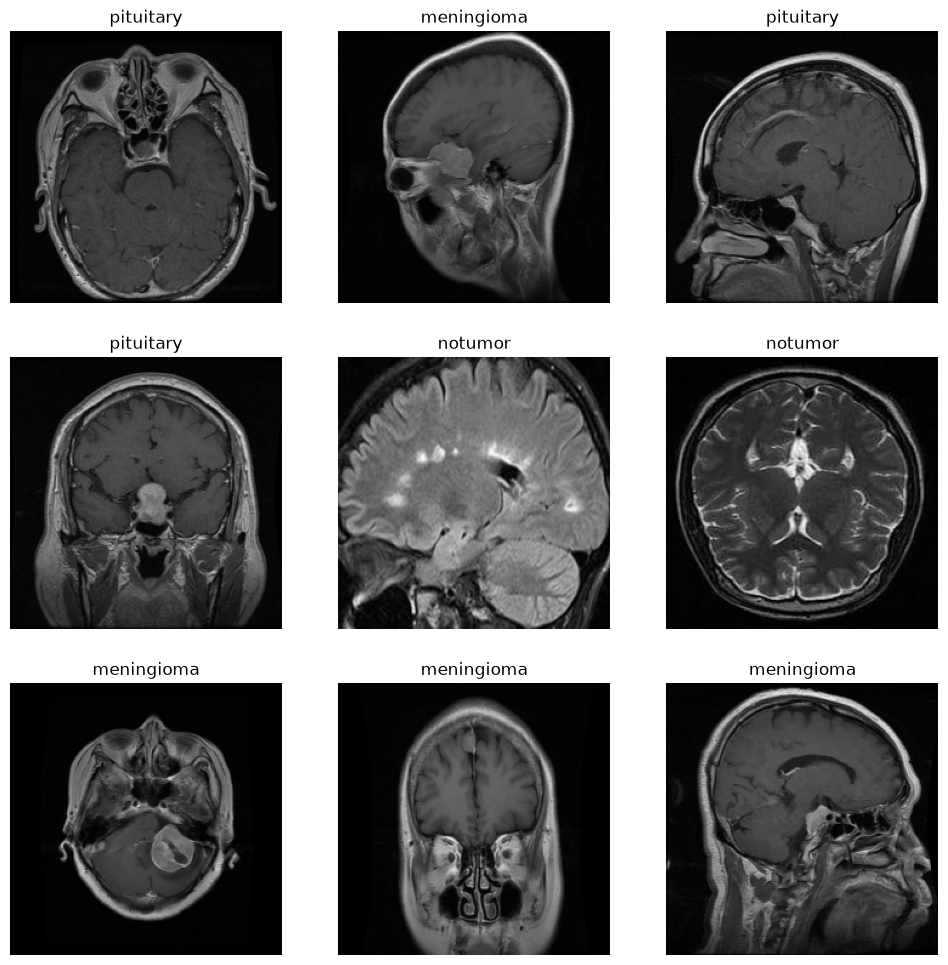

In [10]:
#EXPLORING DATASET
import matplotlib.pyplot as plt
for images,labels in train_dataset.take(1):
    plt.figure(figsize=(12,12))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

In [11]:
# Normalize pixel values to be between 0 and 1 #Ek line mein: pixel values ko 0-1 range mein laana (model ke liye zaroori) + 
#training ko fast banana (cache + prefetch, optional but recommended).
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [12]:
train_dataset = train_dataset.map(lambda images,labels:(normalization_layer(images),labels))
test_dataset = test_dataset.map(lambda images,labels: (normalization_layer(images),labels))

In [13]:
for images,labels in train_dataset.take(1):
    print(images[0].numpy().min())
    print(images[0].numpy().max())

0.0
0.99585813


In [14]:
#Step 10 : Improve Performance
#AUTOTUNE is a special TensorFlow constant that tells TensorFlow. You decide the best setting automatically based on the available CPU, RAM, and GPU.
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [15]:
#CREATE CONVOLUTIONONAL BASE
from tensorflow import keras
from tensorflow.keras import layers, models

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

#ADDING DENSE LAYERS
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(4, activation='softmax'))  # 4 classes — glioma, meningioma, notumor, pituitary
#Ek line mein poora flow:
#Image jaati hai → Conv layers shape/texture patterns nikalte hain → image chhoti hoti jaati hai har pooling ke baad →
#aakhir mein flatten karke Dense layers decide karte hain "ye kaunsi class hai" → 4 probabilities output hoti hain.

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 43264)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       2,768,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,825,540 (10.78 MB)

 Trainable params: 2,825,540 (10.78 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#COMPILE THE MODEL
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # int labels use kiye the (categorical nahi), isliye sparse
    metrics=['accuracy']
)

#TRAIN THE MODEL
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20
)

Epoch 1/20


C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


175/175 ━━━━━━━━━━━━━━━━━━━━ 169s 920ms/step - accuracy: 0.6988 - loss: 0.7316 - val_accuracy: 0.7425 - val_loss: 0.8950
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 143s 814ms/step - accuracy: 0.8586 - loss: 0.3807 - val_accuracy: 0.8044 - val_loss: 0.7211
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 146s 833ms/step - accuracy: 0.9045 - loss: 0.2514 - val_accuracy: 0.8288 - val_loss: 0.9594
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 156s 894ms/step - accuracy: 0.9311 - loss: 0.1760 - val_accuracy: 0.8438 - val_loss: 0.9633
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 163s 932ms/step - accuracy: 0.9511 - loss: 0.1344 - val_accuracy: 0.8625 - val_loss: 1.0639
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 149s 849ms/step - accuracy: 0.9800 - loss: 0.0576 - val_accuracy: 0.8994 - val_loss: 1.2825
Epoch 9/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 138s 786ms/step - accuracy: 0.9775 - loss: 0.0592 - val_accuracy: 0.8975 - val_loss: 1.1891
Epoch 10/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 139s 794ms/step - accuracy: 0.9825 - loss: 0.0

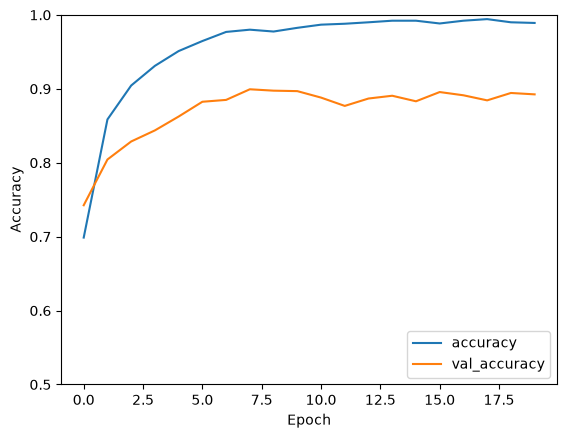

50/50 - 8s - 169ms/step - accuracy: 0.8925 - loss: 1.7362
Test Accuracy: 0.8925


In [18]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()

test_loss, test_acc = model.evaluate(test_dataset, verbose=2)
print(f"Test Accuracy: {test_acc:.4f}")

In [19]:
model.save('brain_tumor_cnn.keras')